In [1]:
import pandas as pd
df = pd.read_csv("../Data/cleaned_app_user_behavior_dataset.csv")

In [2]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_type',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'churn_risk_score', 'engagement_score', 'account_age_days',
       'marketing_source'],
      dtype='str')

In [3]:
features = [
    'age',
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'crash_events_last_30_days',
    'support_tickets_raised',
    'days_since_last_login',
    'ads_clicked_last_30_days',
    'content_downloads',
    'social_shares',
    'engagement_score',
    'account_age_days'
]

X = df[features]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_scaled[:5]

array([[ 1.44582147e+00, -1.06017869e+00, -1.48122134e+00,
         3.86849170e-01,  2.83335661e-01,  1.51219776e-03,
         2.00272957e+00, -8.62410019e-01,  1.24637883e+00,
        -4.61501073e-01, -1.56967510e-01,  1.22456064e+00,
         1.15356206e+00, -1.01880498e-03, -6.16659253e-01,
         1.58643491e+00],
       [ 6.19021691e-01,  1.13097791e-04,  1.08219216e+00,
        -1.60704907e-01, -1.44067656e+00,  8.96303771e-01,
        -5.00094230e-01, -1.02004991e+00, -6.81995987e-01,
        -4.61501073e-01, -1.15811440e+00,  8.16944420e-01,
        -1.30499978e-03,  7.06484656e-01,  1.17595317e+00,
         1.31730970e+00],
       [-5.38498006e-01,  1.41383549e+00, -8.26277748e-01,
         1.61628239e+00, -1.44067656e+00,  1.51219776e-03,
        -1.00065899e+00,  1.18690858e+00,  1.24637883e+00,
        -4.61501073e-01,  8.44179378e-01,  2.03979307e+00,
         1.73099560e+00, -7.08522266e-01, -1.51296546e+00,
         2.14764516e-01],
       [-1.11725786e+00, -1.06017869e

In [6]:
X_scaled.mean()

np.float64(2.8270719099054984e-17)

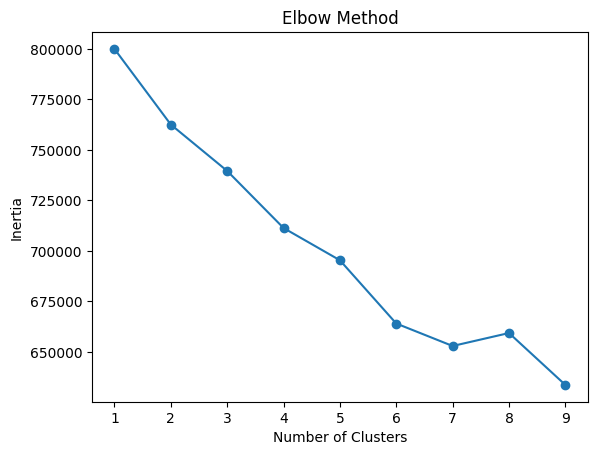

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [9]:
df['cluster'] = clusters

In [10]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df['cluster'] = df['cluster']

numeric_df.groupby('cluster').mean()

,user_id,age,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days
cluster,,,,,,,,,,,,,,,,,,
0,125066.716774,49.559141,8.090287,1.223670,44.148484,11.958395,5.147134,3.965705,13.601835,0.000082,0.089226,22.583405,5.053426,3.044171,1.933898,0.499348,64.579806,608.564818
1,125039.563689,38.652112,7.967688,1.216732,45.007976,12.015930,5.003160,3.981683,13.577878,0.573169,0.099152,22.263528,5.720993,2.991680,1.992325,0.503189,64.906856,602.161690
2,124916.479516,27.634621,7.811220,1.219117,44.667341,12.270019,5.034451,3.945531,13.474162,0.000041,0.097327,22.742706,4.984637,2.859792,2.010940,0.497557,64.822211,588.587756
3,124951.996571,38.056127,8.200846,1.212039,47.668052,11.714678,4.708048,4.157750,13.083219,0.048378,0.108102,19.799726,9.357796,3.169296,2.102881,0.503675,65.704075,622.026063


In [11]:
X_scaled.mean()

np.float64(2.8270719099054984e-17)

In [12]:
cluster_users = df.groupby('cluster')['user_id'].apply(list)

In [13]:
cluster_users

cluster
0    [100004, 100005, 100007, 100011, 100012, 10001...
1    [100000, 100010, 100013, 100015, 100017, 10002...
2    [100003, 100008, 100009, 100014, 100016, 10002...
3    [100001, 100002, 100006, 100034, 100036, 10003...
Name: user_id, dtype: object

In [14]:
df['cluster'].value_counts()

cluster
1    15505
2    12888
0    12859
3     8748
Name: count, dtype: int64

In [15]:
cluster_names = {
    0: "High Users",
    3: "Moderate Users",
    2: "Occasional Users",
    1: "Low Users"
}

df['cluster_name'] = df['cluster'].map(cluster_names)

In [16]:
df.groupby('cluster_name')['user_id'].count()

cluster_name
High Users          12859
Low Users           15505
Moderate Users       8748
Occasional Users    12888
Name: user_id, dtype: int64

In [18]:
cluster_users_named = df.groupby('cluster_name')['user_id'].apply(list)

In [19]:
cluster_summary = df.groupby('cluster').agg({
    'user_id': 'count',
    'sessions_per_week': 'mean',
    'avg_session_duration_min': 'mean',
    'engagement_score': 'mean',
    'days_since_last_login': 'mean',
    'churn_risk_score': 'mean'
}).rename(columns={'user_id': 'user_count'})

cluster_summary

,user_count,sessions_per_week,avg_session_duration_min,engagement_score,days_since_last_login,churn_risk_score
cluster,,,,,,
0,12859,8.090287,1.223670,64.579806,22.583405,0.499348
1,15505,7.967688,1.216732,64.906856,22.263528,0.503189
2,12888,7.811220,1.219117,64.822211,22.742706,0.497557
3,8748,8.200846,1.212039,65.704075,19.799726,0.503675


In [20]:
df[df['cluster_name'] == 'High Users'].head()

,user_id,age,gender,country,device_type,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,marketing_source,cluster,cluster_name
4,100004,38,Male,Australia,Android,10,1.288760,57.06,13,7,...,Basic,4,4,2,0.43,38.21,772,Email Campaign,0,High Users
5,100005,56,Male,India,Android,12,1.236406,25.39,14,7,...,Free,7,3,1,0.65,91.45,50,Email Campaign,0,High Users
7,100007,40,Female,UK,Android,6,1.116912,36.47,14,9,...,Premium,5,6,4,0.51,84.81,104,Organic,0,High Users
11,100011,53,Male,Canada,Android,6,0.913448,45.83,7,3,...,Basic,7,5,2,0.32,74.70,380,Referral,0,High Users
12,100012,57,Male,USA,iOS,5,1.397363,27.22,12,6,...,Free,5,2,1,0.07,62.19,617,Referral,0,High Users


In [21]:
df[df['cluster_name'] == 'Moderate Users'].head()

,user_id,age,gender,country,device_type,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,marketing_source,cluster,cluster_name
1,100001,46,Male,UK,iOS,8,1.443696,42.03,7,7,...,Free,8,3,3,0.87,82.39,1059,Email Campaign,3,Moderate Users
2,100002,32,Female,UK,iOS,12,1.046223,76.69,7,5,...,Free,11,6,1,0.63,42.49,678,Google Ads,3,Moderate Users
6,100006,36,Female,India,Android,8,1.396538,14.86,15,2,...,Free,9,2,1,0.78,63.30,1161,Google Ads,3,Moderate Users
34,100034,38,Female,USA,iOS,11,1.239911,52.53,7,9,...,Free,9,3,3,0.57,54.60,420,Google Ads,3,Moderate Users
36,100036,56,Female,USA,Android,3,1.478282,71.31,12,4,...,Basic,8,5,2,0.43,71.31,847,Organic,3,Moderate Users


In [22]:
df[df['cluster_name'] == 'Low Users'].head()

,user_id,age,gender,country,device_type,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,marketing_source,cluster,cluster_name
0,100000,56,Female,India,iOS,5,0.909820,52.71,13,5,...,Basic,9,5,2,0.31,55.79,1152,Referral,1,Low Users
10,100010,41,Female,Australia,iOS,9,1.101347,51.42,8,5,...,Basic,3,6,3,0.38,56.02,1155,Organic,1,Low Users
13,100013,41,Male,USA,Android,8,1.030230,37.34,8,5,...,Basic,8,5,2,0.48,67.25,255,Organic,1,Low Users
15,100015,39,Female,Singapore,Android,7,1.517987,34.42,13,7,...,Free,6,3,2,0.26,52.69,1130,Organic,1,Low Users
17,100017,41,Female,USA,Android,6,1.356928,74.70,6,6,...,Basic,9,1,1,0.21,100.00,24,Organic,1,Low Users


In [23]:
df[df['cluster_name'] == 'Occasional Users'].head()

,user_id,age,gender,country,device_type,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,...,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,marketing_source,cluster,cluster_name
3,100003,25,Male,India,Android,5,0.957598,65.38,16,8,...,Basic,6,3,1,0.43,62.81,92,Organic,2,Occasional Users
8,100008,28,Female,Germany,Android,7,1.461656,64.74,14,3,...,Free,6,3,5,0.08,72.85,989,Google Ads,2,Occasional Users
9,100009,28,Male,Singapore,Android,8,1.488132,47.77,10,6,...,Free,3,4,2,0.19,55.92,373,Facebook Ads,2,Occasional Users
14,100014,20,Male,USA,iOS,5,1.371236,29.55,16,3,...,Basic,5,0,5,0.98,51.33,691,Google Ads,2,Occasional Users
16,100016,19,Male,India,iOS,7,1.349155,65.07,8,9,...,Free,8,1,3,0.25,73.52,618,Google Ads,2,Occasional Users


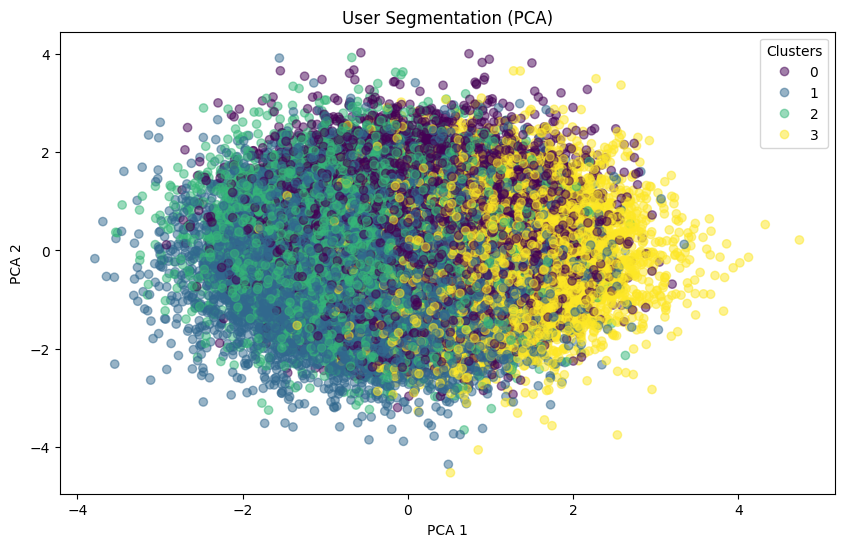

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.5)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("User Segmentation (PCA)")
plt.show()

User Segmentation Overview
High Users (High-Value Customers)
--------------------------------

Behavior:

High session frequency
High engagement score
Frequent app interaction

Insight:
These users are highly active and contribute significantly to platform value.

Business Actions:

Offer loyalty rewards and premium subscriptions
Provide early access to new features
Introduce referral and reward programs

Moderate Users
-----------------

Behavior:

Consistent usage
متوسط engagement
Regular interaction but not intensive

Insight:
These users have potential to become high-value users.

Business Actions:

Personalized recommendations
Feature awareness campaigns
Targeted notifications to increase engagement

Low Users (At-Risk Customers)
-----------------------------

Behavior:

Low engagement
High inactivity (long gaps between logins)

Insight:
These users are at high risk of churn.

Business Actions:

Re-engagement campaigns (emails, push notifications)
Discounts and promotional offers
Improved onboarding experience

Occasional Users
------------------


Behavior:

Irregular usage patterns
Inconsistent engagement

Insight:
These users need motivation to use the app more consistently.

Business Actions:
-----------------

Trigger-based notifications
Highlight key features and benefits
Gamification and engagement incentives

Key Insights
-----------------
User behavior varies significantly across segments
A small portion of users drives high engagement
Inactive users represent churn risk
Engagement can be improved through targeted strategies

Business Impact
----------------

This segmentation enables:

✔ Personalized marketing campaigns
✔ Improved customer retention strategies
✔ Better product feature prioritization
✔ Enhanced user experience
✔ Increased revenue opportunities

Strategic Recommendations
---------------------------
Focus on retaining high-value users through rewards
Convert moderate users into high users via engagement strategies
Reduce churn by targeting low users early
Activate occasional users with personalized experiences
    
Conclusion
------------

This project demonstrates how unsupervised machine learning can 
transform raw user data into actionable insights. 
By segmenting users based on behavior, 
businesses can move from generic strategies to data-driven,
customer-centric decision-making.

In [25]:
from sklearn.cluster import MiniBatchKMeans

mbk = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=1000)
df['mbk_cluster'] = mbk.fit_predict(X_scaled)

In [26]:
df.groupby('mbk_cluster').mean(numeric_only=True)

,user_id,age,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,cluster
mbk_cluster,,,,,,,,,,,,,,,,,,,
0,124943.563105,42.087397,9.163070,1.241580,56.561371,11.602984,5.773515,3.990852,12.576250,0.418985,0.120393,26.019895,5.695088,2.629452,2.246292,0.500800,63.644366,541.821121,1.054534
1,124958.558566,35.939331,7.904613,1.151505,47.724745,12.232052,4.888358,4.288159,14.477579,0.121069,0.086847,12.296571,5.806872,3.802951,1.987096,0.501881,62.822603,456.257432,1.523134
2,125091.041948,30.998110,7.696822,1.218804,43.535135,11.968944,4.464398,3.531281,10.113692,0.138931,0.082827,26.251238,7.710325,2.971285,1.933117,0.501232,66.018262,758.066433,2.068953
3,125013.255200,44.344800,7.382212,1.267526,34.423782,12.165821,4.899890,4.089746,15.914149,0.099434,0.102235,25.346931,5.039471,2.510548,1.869386,0.499458,67.316354,681.191327,0.830798


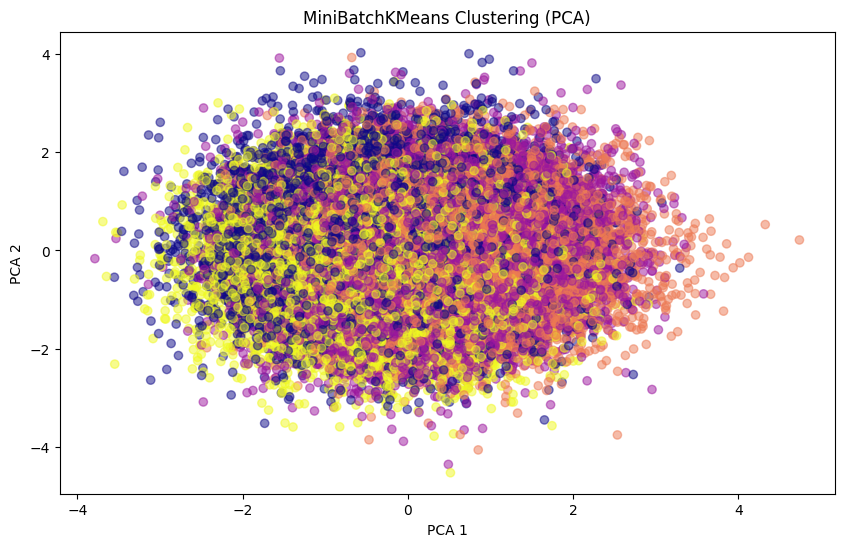

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['mbk_cluster'], cmap='plasma', alpha=0.5)
plt.title("MiniBatchKMeans Clustering (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [28]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

db_clusters = db.fit_predict(X_scaled)

df['db_cluster'] = db_clusters

In [29]:
df['db_cluster'].value_counts()

db_cluster
-1    50000
Name: count, dtype: int64

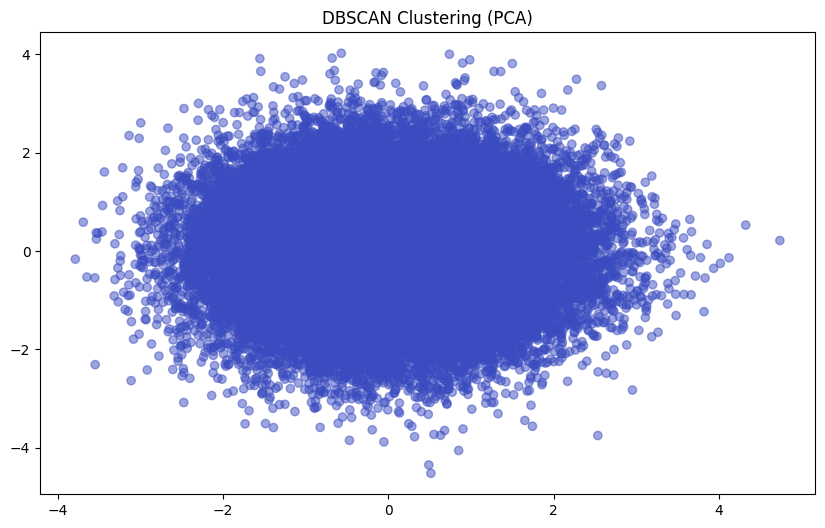

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['db_cluster'], cmap='coolwarm', alpha=0.5)
plt.title("DBSCAN Clustering (PCA)")
plt.show()

In [31]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_clusters = gmm.fit_predict(X_scaled)

df['gmm_cluster'] = gmm_clusters


In [32]:
df.groupby('gmm_cluster').mean(numeric_only=True)

,user_id,age,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,...,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,cluster,mbk_cluster,db_cluster
gmm_cluster,,,,,,,,,,,,,,,,,,,,,
0,125106.043951,49.254374,8.039838,1.221288,45.154041,11.965134,5.031919,4.010804,13.402554,0.000000,...,21.981032,5.987539,3.015100,1.986311,0.500766,65.017173,604.296974,0.695169,1.939660,-1.0
1,125037.205448,38.617999,7.977731,1.216699,45.141642,12.000061,4.983927,3.991841,13.539844,0.571239,...,22.115146,5.991657,3.005521,1.999141,0.504017,64.935238,603.201951,1.097233,0.973437,-1.0
2,124872.217599,28.347203,7.982044,1.217028,45.207813,12.072284,4.976692,3.994878,13.470937,0.000000,...,22.022445,5.990562,2.986073,2.017495,0.497987,64.862531,603.795523,2.199471,1.699471,-1.0
3,120665.593750,36.750000,8.312500,1.219334,38.671875,12.218750,4.312500,3.968750,12.906250,0.000000,...,20.562500,15.156250,3.593750,2.156250,0.460625,70.781875,634.593750,3.000000,1.968750,-1.0


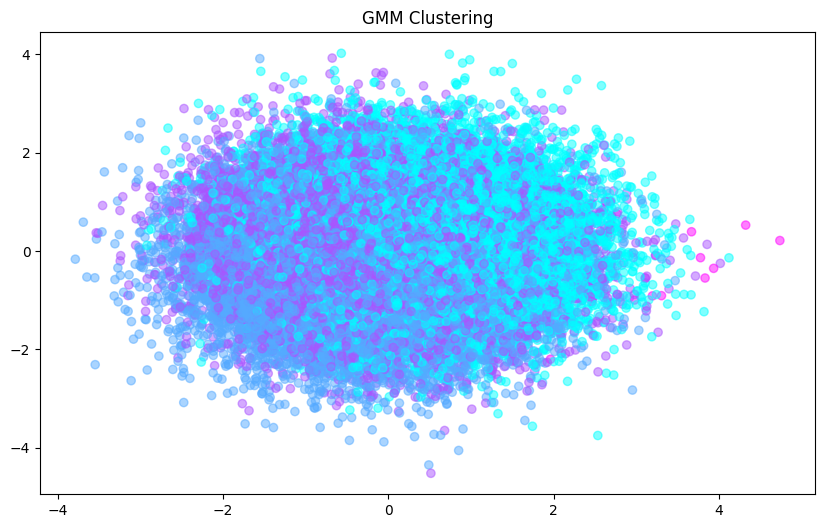

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['gmm_cluster'], cmap='cool', alpha=0.5)
plt.title("GMM Clustering")
plt.show()

In [35]:
df.to_csv("clustered_users.csv", index=False)